In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/customer_churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate Customer IDs: 0


Churn
No     5174
Yes    1869
Name: count, dtype: int64


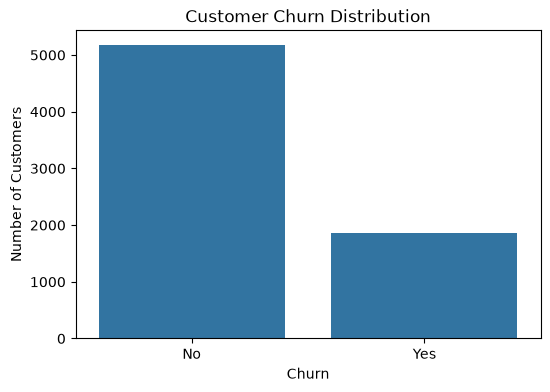

In [7]:
print(df["Churn"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [8]:
# Check TotalCharges values that are not numeric

total_charges_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Invalid TotalCharges values:")
print(df.loc[total_charges_numeric.isna(), ["customerID", "tenure", "TotalCharges"]])

Invalid TotalCharges values:
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             


In [9]:
print("Number of invalid TotalCharges values:",
      total_charges_numeric.isna().sum())

Number of invalid TotalCharges values: 11


In [10]:
df[df["TotalCharges"].str.strip() == " "][
    ["customerID", "tenure", "TotalCharges"]
]

,customerID,tenure,TotalCharges


In [11]:
# Convert TotalCharges from string to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Replace missing TotalCharges with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Verify
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())
print("TotalCharges data type:", df["TotalCharges"].dtype)

Missing TotalCharges: 0
TotalCharges data type: float64


In [12]:
df[df["tenure"] == 0][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
].head(20)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


In [13]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Dataset shape: (7043, 21)

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling     

In [14]:
df = df.drop("customerID", axis=1)

In [15]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())
print("TotalCharges data type:", df["TotalCharges"].dtype)

Missing TotalCharges: 0
TotalCharges data type: float64


In [18]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [19]:
df[df["tenure"] == 0][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
].head(20)

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,0.0,No
753,0,20.25,0.0,No
936,0,80.85,0.0,No
1082,0,25.75,0.0,No
1340,0,56.05,0.0,No
3331,0,19.85,0.0,No
3826,0,25.35,0.0,No
4380,0,20.00,0.0,No
5218,0,19.70,0.0,No
6670,0,73.35,0.0,No


In [20]:
# Reload the original dataset
df = pd.read_csv("../data/customer_churn.csv")

# Clean TotalCharges
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Shape:", df.shape)
print("Columns:", len(df.columns))
print("Missing values:", df.isnull().sum().sum())
print("TotalCharges dtype:", df["TotalCharges"].dtype)

Shape: (7043, 21)
Columns: 21
Missing values: 0
TotalCharges dtype: float64


In [21]:
df[df["tenure"] == 0][
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
].head(20)

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,0.0,No
753,3115-CZMZD,0,20.25,0.0,No
936,5709-LVOEQ,0,80.85,0.0,No
1082,4367-NUYAO,0,25.75,0.0,No
1340,1371-DWPAZ,0,56.05,0.0,No
3331,7644-OMVMY,0,19.85,0.0,No
3826,3213-VVOLG,0,25.35,0.0,No
4380,2520-SGTTA,0,20.00,0.0,No
5218,2923-ARZLG,0,19.70,0.0,No
6670,4075-WKNIU,0,73.35,0.0,No


In [22]:
# Churn by Contract

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


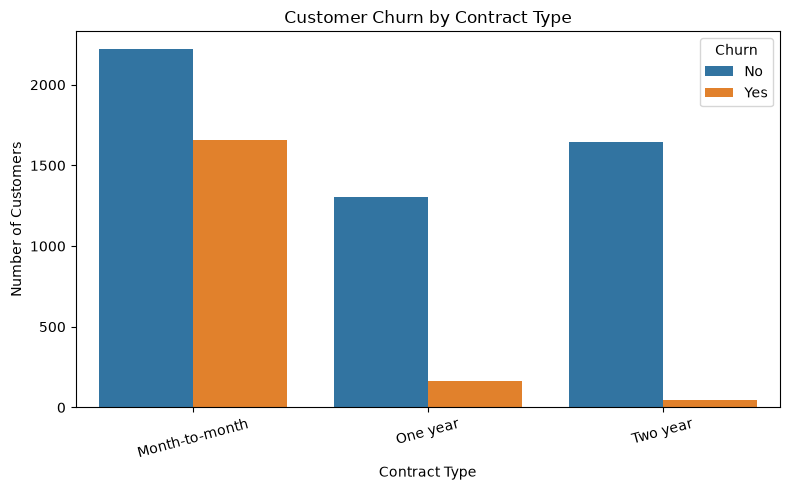

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [24]:
contract_churn_rate = (
    df.groupby("Contract")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(contract_churn_rate)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64


In [25]:
df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 60, 72],
    labels=[
        "0-1 Year",
        "1-2 Years",
        "2-4 Years",
        "4-5 Years",
        "5-6 Years"
    ]
)

In [26]:
tenure_churn = (
    df.groupby("TenureGroup", observed=True)["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(tenure_churn)

TenureGroup
0-1 Year     47.438243
1-2 Years    28.710938
2-4 Years    20.388959
4-5 Years    14.423077
5-6 Years     6.609808
Name: Churn, dtype: float64


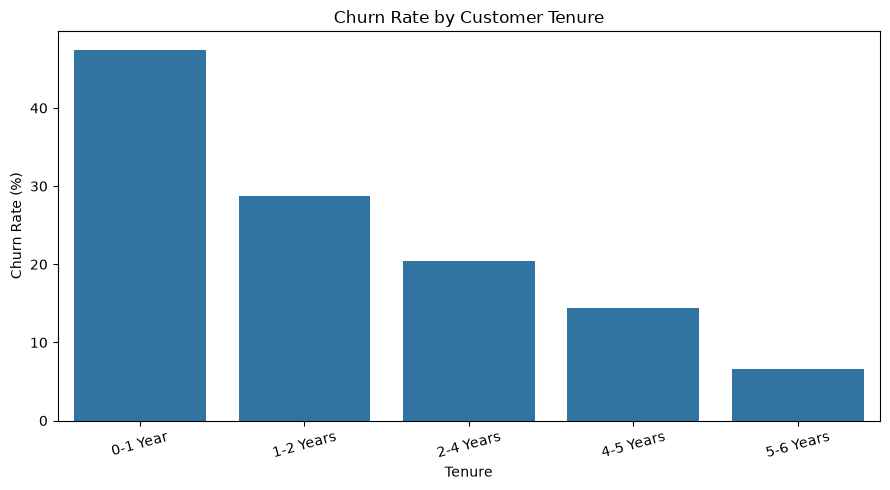

In [27]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

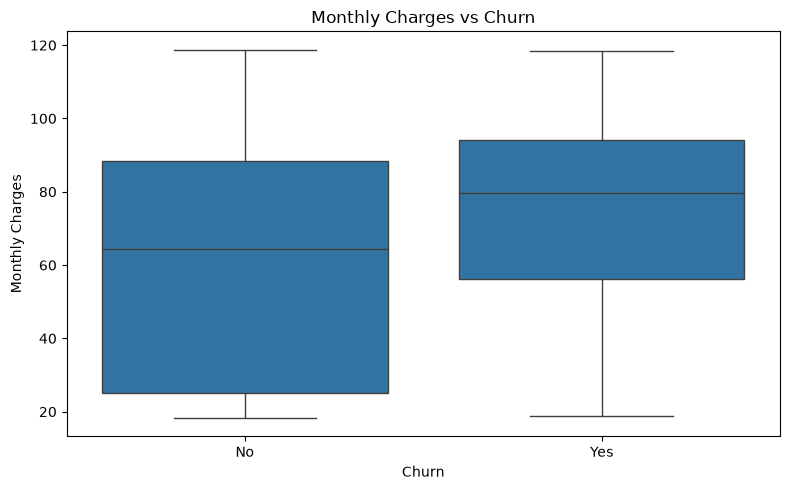

In [28]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [29]:
print(
    df.groupby("Churn")["MonthlyCharges"]
    .agg(["mean", "median", "min", "max"])
)

            mean  median    min     max
Churn                                  
No     61.265124  64.425  18.25  118.75
Yes    74.441332  79.650  18.85  118.35


In [30]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


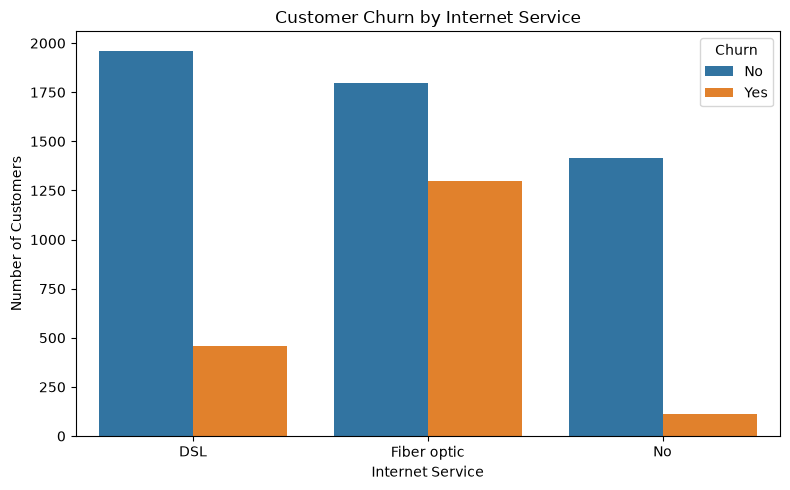

In [31]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [32]:
internet_churn_rate = (
    df.groupby("InternetService")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(internet_churn_rate)

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: Churn, dtype: float64


In [33]:
payment_churn_rate = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print(payment_churn_rate)

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: Churn, dtype: float64


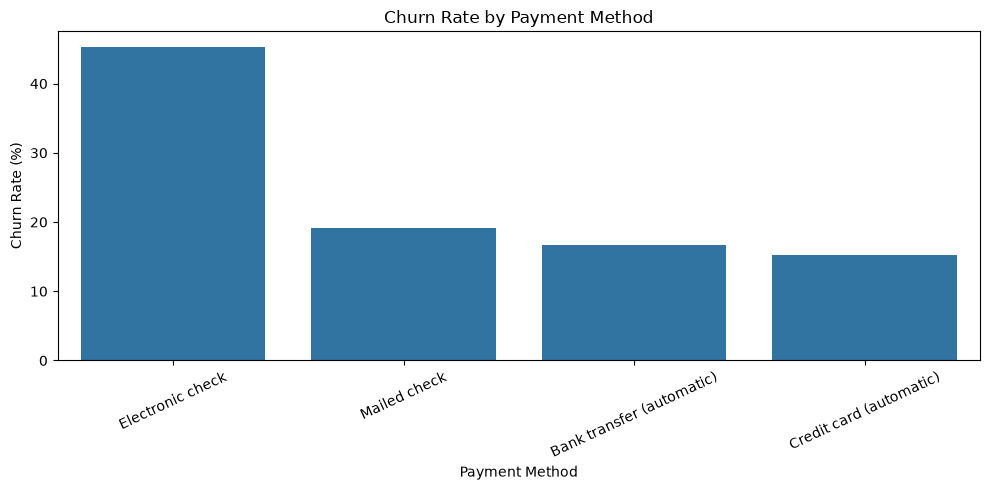

In [34]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=payment_churn_rate.index,
    y=payment_churn_rate.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

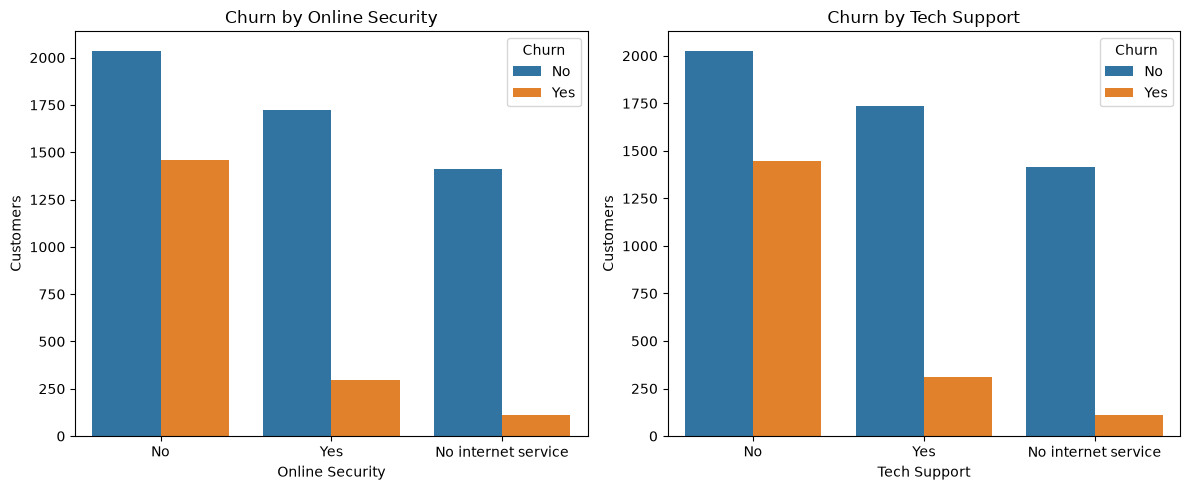

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn",
    ax=axes[0]
)

axes[0].set_title("Churn by Online Security")
axes[0].set_xlabel("Online Security")
axes[0].set_ylabel("Customers")

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn",
    ax=axes[1]
)

axes[1].set_title("Churn by Tech Support")
axes[1].set_xlabel("Tech Support")
axes[1].set_ylabel("Customers")

plt.tight_layout()
plt.show()

In [36]:
for column in ["OnlineSecurity", "TechSupport"]:
    rate = (
        df.groupby(column)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )
    
    print(f"\n{column} churn rate:")
    print(rate)


OnlineSecurity churn rate:
OnlineSecurity
No                     41.766724
Yes                    14.611194
No internet service     7.404980
Name: Churn, dtype: float64

TechSupport churn rate:
TechSupport
No                     41.635474
Yes                    15.166341
No internet service     7.404980
Name: Churn, dtype: float64


In [37]:
df["TenureGroup"]

0        0-1 Year
1       2-4 Years
2        0-1 Year
3       2-4 Years
4        0-1 Year
          ...    
7038    1-2 Years
7039    5-6 Years
7040     0-1 Year
7041     0-1 Year
7042    5-6 Years
Name: TenureGroup, Length: 7043, dtype: category
Categories (5, str): ['0-1 Year' < '1-2 Years' < '2-4 Years' < '4-5 Years' < '5-6 Years']

In [38]:
df = df.drop(columns=["TenureGroup"])

In [39]:
print(df.shape)
print("TenureGroup" in df.columns)

(7043, 21)
False


In [40]:
senior_churn = (
    df.groupby("SeniorCitizen")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(senior_churn)

SeniorCitizen
0    23.606168
1    41.681261
Name: Churn, dtype: float64


In [41]:
partner_churn = (
    df.groupby("Partner")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(partner_churn)

Partner
No     32.957979
Yes    19.664903
Name: Churn, dtype: float64


In [42]:
dependent_churn = (
    df.groupby("Dependents")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(dependent_churn)

Dependents
No     31.279140
Yes    15.450237
Name: Churn, dtype: float64


In [43]:
paperless_churn = (
    df.groupby("PaperlessBilling")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

print(paperless_churn)

PaperlessBilling
No     16.330084
Yes    33.565092
Name: Churn, dtype: float64


In [44]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

print(
    df.groupby("Churn")[numeric_cols]
    .agg(["mean", "median"])
)

          tenure        MonthlyCharges         TotalCharges          
            mean median           mean  median         mean    median
Churn                                                                
No     37.569965   38.0      61.265124  64.425  2549.911442  1679.525
Yes    17.979133   10.0      74.441332  79.650  1531.796094   703.550


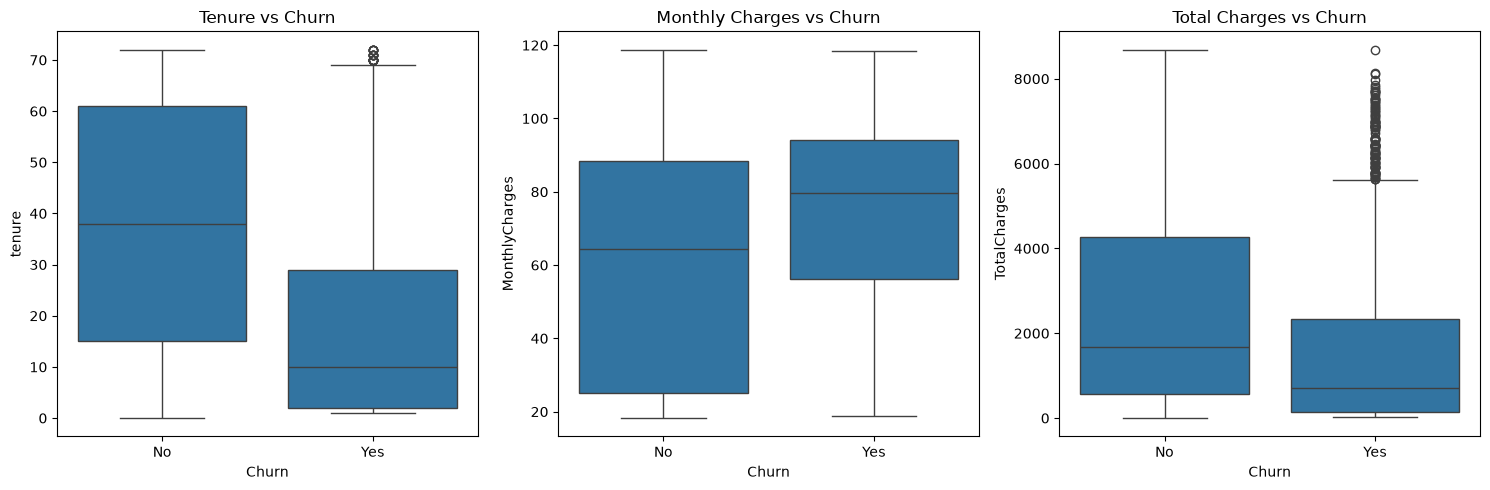

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0])
axes[0].set_title("Tenure vs Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Monthly Charges vs Churn")

sns.boxplot(data=df, x="Churn", y="TotalCharges", ax=axes[2])
axes[2].set_title("Total Charges vs Churn")

plt.tight_layout()
plt.show()